# SINDy Quick Evaluation: Lorenz96
Simple setup focused on the Lorenz-96 system. Configure the system/optimizer, fit SINDy, inspect the discovered equations, and compare trajectories.

In [12]:
# If pysindy is missing, uncomment the next line in a fresh runtime
# %pip install pysindy

In [13]:
import os, sys, time

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import matplotlib.pyplot as plt
import pysindy as ps

sys.path.append("../utilities")
import DataGenerator as DG

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True


## Choose system and optimizer
- `SYSTEM_NAME` must match a key from `DataGenerator.model_mappings` (e.g., `lorenz`, `lorenz96`, `duffing`, `dnls_split`).
- `MODEL_ARGS` are optional positional args forwarded to the model (e.g., `(2.0, N_sites)` for DNLS variants).
- Adjust the optimizer block to try STLSQ/Lasso/Ridge/SR3 with your own hyperparameters.

In [44]:
# System configuration (Lorenz-96 defaults)
SYSTEM_NAME = "lorenz_96"     # Keep as lorenz96 unless you want to test another system
STATE_DIM = 5                # Number of state variables (N in Lorenz-96)
MODEL_ARGS = ()               # Optional args for the system; Lorenz-96 uses F (default 8) if provided

T_MAX = 50.0
DT = 0.01
NUM_TRAJ = 1
NOISE_LEVEL = 1.0
DERIVATIVE_MODE = "exact"      # "exact" or "finite_difference"
SOLVER_KWARGS = {"method": "DOP853"}
RANDOM_SEED = 42

# SINDy configuration
POLY_DEGREE = 10              # Polynomial feature degree
OPTIMIZER_NAME = "stlsq"      # Options: stlsq, lasso, ridge, sr3
OPTIMIZER_KWARGS = {"threshold": 0.02}

# To bypass OPTIMIZER_NAME/KWARGS, set an explicit optimizer instance, e.g.:
# OPTIMIZER_INSTANCE = ps.STLSQ(alpha=2, threshold=0.0)
OPTIMIZER_INSTANCE = None


In [45]:
# Generate data
np.random.seed(RANDOM_SEED)
initial_conditions = DG.DataGenerator.generate_initial_conditions(
    STATE_DIM, num_conditions=NUM_TRAJ, seed=RANDOM_SEED
)

dg = DG.DataGenerator(
    initial_conditions,
    T=T_MAX,
    dt=DT,
    derivative_mode=DERIVATIVE_MODE,
    noise_level=NOISE_LEVEL,
    random_state=RANDOM_SEED,
)

t_arr, x_train, dx_train, guessed_order = dg.generate_dataset_by_model_name(
    SYSTEM_NAME, *MODEL_ARGS, **SOLVER_KWARGS
)

# Reshape to recover individual trajectories
n_steps = len(t_arr)
x_train = x_train.reshape(NUM_TRAJ, n_steps, STATE_DIM)
dx_train = dx_train.reshape(NUM_TRAJ, n_steps, STATE_DIM)

training_input = x_train[0]
training_output = dx_train[0]
t_eval = t_arr.flatten()

print(f"System: {SYSTEM_NAME}")
print(f"Samples: {training_input.shape[0]} | State dim: {training_input.shape[1]}")
print(f"Time span: {t_eval[0]:.3f} -> {t_eval[-1]:.3f} (dt={DT})")
print(f"Guessed polynomial order: {guessed_order}")


System: lorenz_96
Samples: 5000 | State dim: 5
Time span: 0.000 -> 49.990 (dt=0.01)
Guessed polynomial order: 2


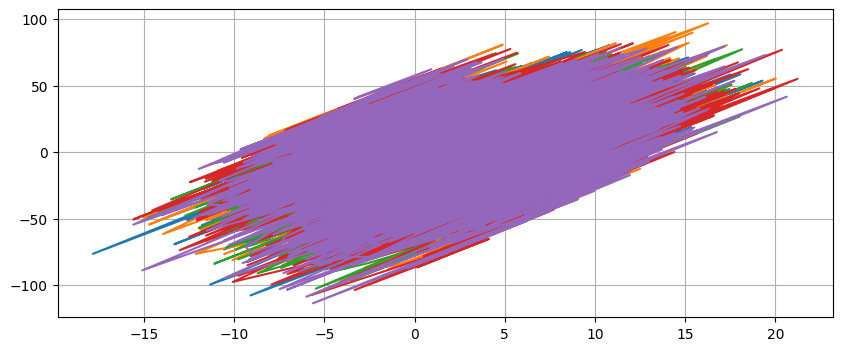

In [46]:
import matplotlib.pyplot as plt
plt.plot(x_train[0], dx_train[0])
plt.show()

In [47]:
# Build and fit the SINDy model
# Match ablation notebooks: lasso/ridge mapped to STLSQ with alpha.

feature_library = ps.PolynomialLibrary(degree=POLY_DEGREE)
#STLSQ
optimizer = ps.STLSQ(threshold=0.001)

#SR3
#optimizer = ps.SR3(trimming_fraction=0.1)

model = ps.SINDy(feature_library=feature_library, optimizer=optimizer)

start = time.time()
model.fit(training_input, t=DT, x_dot=training_output)
fit_time = time.time() - start

print(f"Optimizer: {optimizer}")
print(f"Fit time: {fit_time:.3f}s")


Optimizer: STLSQ(threshold=0.001)
Fit time: 14.164s


In [ ]:

# Get data matrix (library matrix Theta)
feature_library.fit(training_input)
Theta = feature_library.transform(training_input)

print("\n" + "="*60)
print("Data Matrix (Library Matrix) Analysis")
print("="*60)
print(f"Matrix shape: {Theta.shape}")
print(f"  - Number of samples: {Theta.shape[0]}")
print(f"  - Number of features: {Theta.shape[1]}")

# Check if matrix is singular
matrix_rank = np.linalg.matrix_rank(Theta)
print(f"\nMatrix rank: {matrix_rank} / {Theta.shape[1]} features")
print(f"  - Full rank: {matrix_rank == Theta.shape[1]}")
print(f"  - Rank deficient: {matrix_rank < Theta.shape[1]}")

# Check condition number
cond_number = np.linalg.cond(Theta)
print(f"\nCondition number: {cond_number:.2e}")
if cond_number > 1e12:
    print("  - Matrix is numerically singular (condition number > 1e12)")
elif cond_number > 1e8:
    print("  - Matrix is ill-conditioned (condition number > 1e8)")
else:
    print("  - Matrix is well-conditioned")

# Check if square matrix and compute determinant
if Theta.shape[0] == Theta.shape[1]:
    det = np.linalg.det(Theta)
    print(f"\nDeterminant: {det:.2e}")
    if abs(det) < 1e-10:
        print("  - Matrix is singular (determinant ≈ 0)")
    else:
        print("  - Matrix is non-singular")
else:
    print("\nMatrix is not square, cannot compute determinant")

# Check singular values
singular_values = np.linalg.svd(Theta, compute_uv=False)
min_sv = singular_values.min()
print(f"\nSingular values:")
print(f"  - Minimum singular value: {min_sv:.2e}")
print(f"  - Maximum singular value: {singular_values.max():.2e}")
if min_sv < 1e-10:
    print("  - Matrix is singular (minimum singular value ≈ 0)")
else:
    print("  - Matrix is non-singular")

# Check for linearly dependent columns
if matrix_rank < Theta.shape[1]:
    print(f"\nWarning: Matrix has {Theta.shape[1] - matrix_rank} linearly dependent columns")
print("="*60)




Data Matrix (Library Matrix) Analysis
Matrix shape: (5000, 3003)
  - Number of samples: 5000
  - Number of features: 3003


KeyboardInterrupt: 

In [48]:
# Show discovered equations
print("Discovered system:")
model.print()

Discovered system:
(x0)' = -9.896 1 + 2.306 x0 + 1.514 x1 + 1.263 x2 + 0.488 x3 + -1.206 x4 + -0.028 x0^2 + 0.058 x0 x1 + 0.008 x0 x2 + -0.061 x0 x3 + -0.044 x0 x4 + -0.066 x1^2 + -0.043 x1 x2 + -0.009 x1 x3 + 0.148 x1 x4 + 0.008 x2^2 + -0.064 x2 x3 + -0.059 x2 x4 + 0.069 x3^2 + -0.163 x3 x4 + 0.007 x4^2 + 0.004 x0^3 + -0.002 x0^2 x1 + -0.004 x0^2 x2 + 0.003 x0^2 x3 + 0.006 x0^2 x4 + 0.009 x0 x1^2 + -0.006 x0 x1 x3 + -0.009 x0 x2 x3 + -0.005 x0 x2 x4 + 0.005 x0 x3^2 + 0.004 x0 x4^2 + -0.002 x1^3 + -0.004 x1^2 x2 + -0.001 x1^2 x4 + 0.006 x1 x2 x3 + 0.016 x1 x2 x4 + -0.002 x1 x3^2 + -0.001 x1 x3 x4 + -0.009 x1 x4^2 + 0.005 x2^2 x4 + -0.002 x2 x3^2 + -0.002 x3^3 + 0.002 x4^3 + 0.001 x0 x2 x3^2 + 0.001 x1^2 x3 x4
(x1)' = -7.640 1 + -1.490 x0 + 1.896 x1 + 1.704 x2 + 1.267 x3 + 0.846 x4 + 0.012 x0^2 + 0.035 x0 x1 + 0.193 x0 x2 + 0.013 x0 x3 + -0.137 x0 x4 + -0.025 x1^2 + 0.082 x1 x2 + 0.034 x1 x3 + -0.074 x1 x4 + -0.123 x2^2 + -0.092 x2 x3 + -0.041 x2 x4 + -0.003 x3^2 + -0.086 x3 x4 + 0.060 

In [20]:
# Evaluate derivative and trajectory errors

dx_pred = model.predict(training_input)
derivative_rmse = np.sqrt(np.mean((dx_pred - training_output) ** 2))

sim_pred = model.simulate(training_input[0], t_eval)
trajectory_rmse = np.sqrt(np.mean((sim_pred - training_input) ** 2))


capi_return is NULL
Call-back cb_f_in_lsoda__user__routines failed.


KeyboardInterrupt: 

In [ ]:

print(f"Derivative RMSE: {derivative_rmse:.12f}")
print(f"Trajectory RMSE: {trajectory_rmse:.12f}")

Derivative RMSE: 0.000000000003
Trajectory RMSE: 0.000000060398


In [ ]:
# Complexity and accuracy summary
coeff = model.coefficients()
nonzero = np.count_nonzero(coeff)
per_eq = np.count_nonzero(coeff, axis=1)
sparsity = 1 - nonzero / coeff.size
traj_mae = np.mean(np.abs(sim_pred - training_input))

print("Model complexity:")
print(f"  total coefficients: {coeff.size}")
print(f"  non-zero coefficients: {nonzero}")
print(f"  sparsity: {sparsity:.4f} ({sparsity*100:.2f}%)")
print(f"  avg active terms per equation: {per_eq.mean():.2f}")

print("Accuracy:")
print(f"  derivative RMSE: {derivative_rmse:.6f}")
print(f"  trajectory RMSE: {trajectory_rmse:.6f}")
print(f"  trajectory MAE: {traj_mae:.6f}")


Model complexity:
  total coefficients: 35420
  non-zero coefficients: 8258
  sparsity: 0.7669 (76.69%)
  avg active terms per equation: 412.90
Accuracy:
  derivative RMSE: 0.000000
  trajectory RMSE: 0.000000
  trajectory MAE: 0.000000


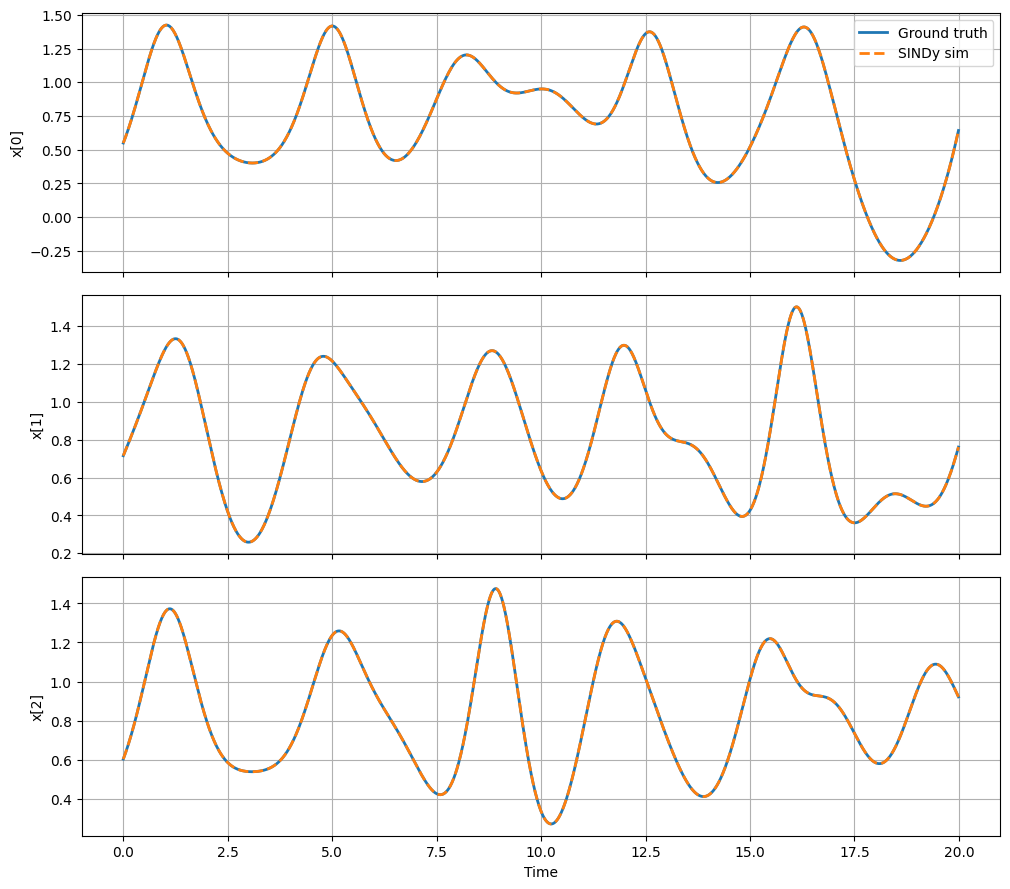

In [ ]:
# Plot ground truth vs. SINDy simulation
n_plot = min(3, training_input.shape[1])
fig, axes = plt.subplots(n_plot, 1, figsize=(10, 3 * n_plot), sharex=True)
if n_plot == 1:
    axes = [axes]

for idx, ax in enumerate(axes[:n_plot]):
    ax.plot(t_eval, training_input[:, idx], label="Ground truth", linewidth=2)
    ax.plot(t_eval, sim_pred[:, idx], "--", label="SINDy sim", linewidth=2)
    ax.set_ylabel(f"x[{idx}]")

axes[-1].set_xlabel("Time")
axes[0].legend()
plt.tight_layout()
plt.show()


Run the cells again after tweaking the configuration to try new systems or optimizers.